In [21]:
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from collections import Counter
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
import numpy as nm
import matplotlib.pyplot as mtp  
# import scikitplot as skplt

In [2]:
strokeDf = pd.read_csv("healthcare-dataset-stroke-data.csv")
strokeDf = strokeDf.drop(["id"], axis = 1)

strokeDf.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print(strokeDf.isnull().sum())

strokeDf = strokeDf.dropna()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [4]:
strokeDf.isnull().values.any()

False

Label Encoded data

OneHot Encoded data

In [5]:
oneHotDf = pd.get_dummies(strokeDf, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

oneHotDf.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.0,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [6]:
xOneHot = oneHotDf.drop(['stroke'], axis = 1)
yOneHot = oneHotDf['stroke']



In [7]:
oversample = SMOTE()
xOneHot, yOneHot = oversample.fit_resample(xOneHot, yOneHot)
print(Counter(yOneHot))

Counter({1: 4700, 0: 4700})


In [8]:
xOneHot_train, xOneHot_test, yOneHot_train, yOneHot_test = train_test_split(xOneHot, yOneHot, random_state = 42, stratify = yOneHot, train_size = 0.75)
counter = Counter(yOneHot_train)
print(counter)

Counter({0: 3525, 1: 3525})


In [9]:
scaler=StandardScaler()
con_cols=['age','avg_glucose_level','bmi']
xOneHot_train[con_cols]=scaler.fit_transform(xOneHot_train[con_cols])
xOneHot_test[con_cols]=scaler.transform(xOneHot_test[con_cols])
xOneHot_train.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2731,0.093038,0,0,-0.528809,0.604722,0,1,0,0,1,...,0,1,0,0,1,0,0,0,1,0
4621,-1.727253,0,0,-0.722805,-0.797294,1,0,0,1,0,...,0,1,0,0,0,1,1,0,0,0
5019,1.124771,0,0,-0.324997,-0.980773,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3761,-1.044644,0,0,-0.340847,2.094364,1,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
8870,0.985735,1,0,1.373927,-0.283719,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0


In [10]:
classifier_oneHotKNN = KNeighborsClassifier(n_neighbors=2)

classifier_oneHotKNN.fit(xOneHot_train, yOneHot_train)

oneHotKNN = classifier_oneHotKNN.predict(xOneHot_test)

print(confusion_matrix(yOneHot_test, oneHotKNN))
print('accuracy score :',accuracy_score(oneHotKNN,yOneHot_test))
print('Precision Score :',precision_score(oneHotKNN, yOneHot_test, average='weighted'))


[[1158   17]
 [  37 1138]]
accuracy score : 0.9770212765957447
Precision Score : 0.977166138524219


In [11]:
param_grid = {"n_neighbors":range(1,30), "p": [1,2], "weights": ['uniform', "distance"]}
knn_grid_model = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring= 'recall')

knn_grid_model.fit(xOneHot_train, yOneHot_train)
knn_grid_model.best_params_

{'n_neighbors': 18, 'p': 1, 'weights': 'distance'}

In [15]:
classifier_oneHotKNN = KNeighborsClassifier(n_neighbors = 18, p = 1, weights = 'distance')

classifier_oneHotKNN.fit(xOneHot_train, yOneHot_train)

oneHotKNN = classifier_oneHotKNN.predict(xOneHot_test)

print(confusion_matrix(yOneHot_test, oneHotKNN))
print('accuracy score :',accuracy_score(oneHotKNN,yOneHot_test))
print('Precision Score :',precision_score(oneHotKNN, yOneHot_test, average='weighted'))

[[1119   56]
 [  23 1152]]
accuracy score : 0.9663829787234043
Precision Score : 0.9667773653236759


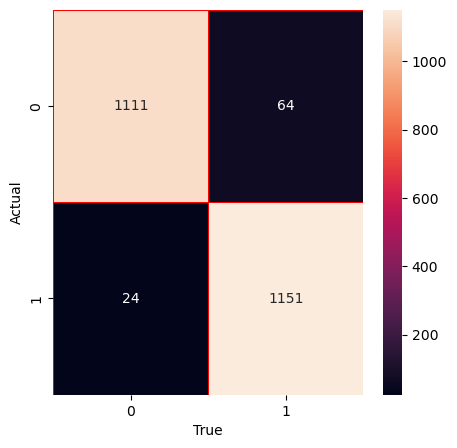

In [13]:


cm= confusion_matrix(yOneHot_test, oneHotKNN)

f, ax =plt.subplots(figsize = (5,5))

sns.heatmap(cm,annot = True, linewidths= 0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("True")
plt.ylabel("Actual")
plt.show()

In [36]:
h = xOneHot_train[:]
print(h)

           age  hypertension  heart_disease  avg_glucose_level       bmi  \
2731  0.093038             0              0          -0.528809  0.604722   
4621 -1.727253             0              0          -0.722805 -0.797294   
5019  1.124771             0              0          -0.324997 -0.980773   
3761 -1.044644             0              0          -0.340847  2.094364   
8870  0.985735             1              0           1.373927 -0.283719   
...        ...           ...            ...                ...       ...   
1347 -0.817108             0              0          -0.880060  0.911413   
2575 -0.316528             0              0          -0.747121  0.487887   
5923 -0.168501             0              0          -0.145705  1.841442   
3935 -0.862615             0              0          -0.855034 -0.928733   
8045 -0.832785             0              0          -0.700642 -0.299909   

      gender_Female  gender_Male  gender_Other  ever_married_No  \
2731              0 

In [22]:
 
x_set, y_set = xOneHot_train, yOneHot_train  
x1, x2 = nm.meshgrid(nm.arange(start = x_set[:, 0].min() - 1, stop = x_set[:, 0].max() + 1, step  =0.01),  
nm.arange(start = x_set[:, 1].min() - 1, stop = x_set[:, 1].max() + 1, step = 0.01))  
mtp.contourf(x1, x2, classifier_oneHotKNN.predict(nm.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),  
alpha = 0.75, cmap = ListedColormap(('red','green' )))  
mtp.xlim(x1.min(), x1.max())  
mtp.ylim(x2.min(), x2.max())  
for i, j in enumerate(nm.unique(y_set)):  
    mtp.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],  
        c = ListedColormap(('red', 'green'))(i), label = j)  
mtp.title('K-NN Algorithm (Training set)')  
mtp.xlabel('Age')  
mtp.ylabel('Estimated Salary')  
mtp.legend()  
mtp.show()  

InvalidIndexError: (slice(None, None, None), 0)

In [14]:
parameters = {
    'C':[0.001, 0.01,0.1,1,10, 100, 1000], 
    'gamma':[0.001, 0.01,0.1,1,100, 1000]
}

svm = RandomizedSearchCV(SVC(probability= True), parameters, cv=5)
svm.fit(xOneHot_train,yOneHot_train)
y_pred_svm = svm.predict(xOneHot_test)
y_pred_prob_svm = svm.predict_proba(xOneHot_test)[:, 1]

# cm= confusion_matrix(yOneHot_test, y_pred_svm)
# sns.heatmap(cm,annot = True, linewidths= 0.5, linecolor="red", fmt=".0f", ax=ax)
print('Accuracy:', accuracy_score(yOneHot_test, y_pred_svm))
# print('ROC AUC Score:', roc_auc_score(yOneHot_test, y_pred_prob_svm))

Accuracy: 0.9740425531914894


[[1160   15]
 [  46 1129]]


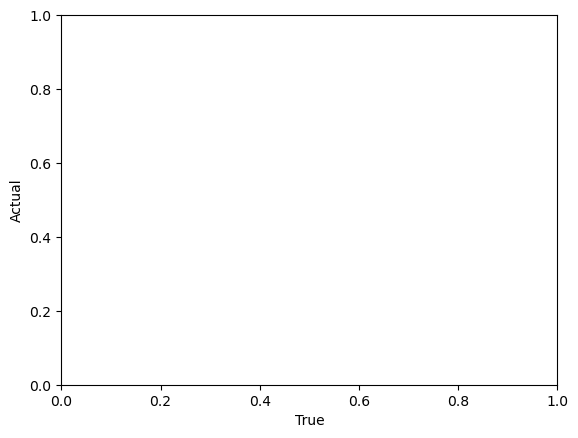

In [18]:
cm= confusion_matrix(yOneHot_test, y_pred_svm)
print(confusion_matrix(yOneHot_test, y_pred_svm))
sns.heatmap(cm,annot = True, linewidths= 0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("True")
plt.ylabel("Actual")
plt.show()